# E03 — régler le lissage sur le dev

E02 montre que 1 est trop et 0.001 pas assez. Quelle valeur entre les deux
minimise la loss en dev ?

In [1]:
words = open('names.txt', 'r').read().splitlines()

In [2]:
import torch
import random
import matplotlib.pyplot as plt

In [3]:
random.seed(42)
ws = words[:] # copie, on ne mélange pas words en place
random.shuffle(ws)
n1, n2 = int(0.8 * len(ws)), int(0.9 * len(ws))
train, dev, test = ws[:n1], ws[n1:n2], ws[n2:]
print(len(train), len(dev), len(test))

25626 3203 3204


In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}

## Données et comptages

In [5]:
def trigrams(ws):
    out = []
    for w in ws:
        chs = ['.', '.'] + list(w) + ['.']
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            out.append((stoi[ch1], stoi[ch2], stoi[ch3]))
    return torch.tensor(out)

tri_train, tri_dev, tri_test = trigrams(train), trigrams(dev), trigrams(test)

In [6]:
def counts3(tri):
    N = torch.zeros((27, 27, 27), dtype=torch.int32)
    for i, j, k in tri:
        N[i, j, k] += 1
    return N

N3 = counts3(tri_train)

In [7]:
def proba3(N, smooth):
    P = (N + smooth).float()
    return P / P.sum(2, keepdim=True)

def loss3(P, tri):
    return -P[tri[:, 0], tri[:, 1], tri[:, 2]].log().mean().item()

## Balayage

meilleur lissage : 0.1274  dev 2.2222


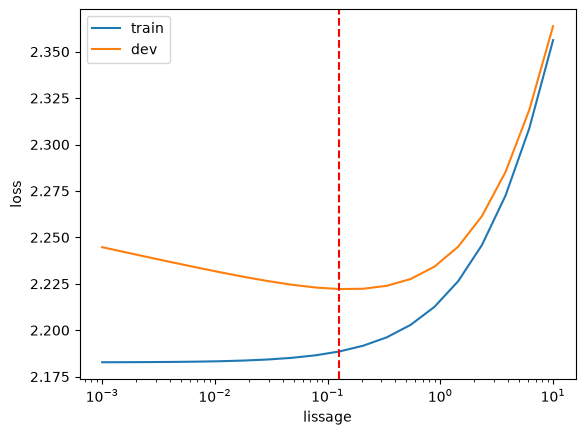

In [8]:
smooths = torch.logspace(-3, 1, 20)
l_train, l_dev = [], []

for sm in smooths:
    P3 = proba3(N3, sm.item())
    l_train.append(loss3(P3, tri_train))
    l_dev.append(loss3(P3, tri_dev))

best = smooths[torch.tensor(l_dev).argmin()].item()
print(f'meilleur lissage : {best:.4f}  dev {min(l_dev):.4f}')

plt.plot(smooths, l_train, label='train')
plt.plot(smooths, l_dev, label='dev')
plt.axvline(best, color='r', ls='--')
plt.xscale('log')
plt.xlabel('lissage'); plt.ylabel('loss'); plt.legend();

## Évaluation finale

In [9]:
P3 = proba3(N3, best)
print(f'test {loss3(P3, tri_test):.4f}')

test 2.2236
